# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [14]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- No se observan nulos en ninguna columna
- La columna 'converted' es de tipo int pero debería ser bool
- La columna 'date' es de tipo object y debería ser tipo fecha

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [12]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [13]:
# Explorar variables categóricas y cómo se distribuyen
cols_cat = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

print("\nConteo de categorías:")
for col in cols_cat:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100)  # en porcentaje


Conteo de categorías:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64
B    50.0
A    50.0
Name: landing, dtype: float64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
Norte        27.9
Centro       24.0
Sur          20.1
Occidente    16.0
Oriente      12.0
Name: region, dtype: float64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
Mobile     62.1
Desktop    37.9
Name: dispositivo, dtype: float64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
Organic     45.0
Ads         29.8
Email       15.3
Referral     9.9
Name: traffic_source, dtype: float64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
Nuevo         65.1
Recurrente    34.9
Name: user_type, dtype: float64


In [15]:
df['date'] = pd.to_datetime(df['date'])

**Hallazgos**

- Las variables categóricas no tienen errores: no hay categorías mal escritas, duplicadas por mayúsculas/minúsculas ni valores inesperados. Cada columna tiene solo las categorías esperadas:

- Los grupos del experimento están balanceados: A tiene 19,982 usuarios y B 20,018 (50% cada uno), así que la asignación parece correcta.
- La mayor parte del tráfico es Mobile (62.1%), Organic (45%) y usuarios Nuevos (65.1%). Norte es la región con más usuarios (27.9%) y Oriente la que menos (12%).
- Revisando el resto de la base, no hay nulos, `user_id` es único en las 40,000 filas y `gasto` no tiene valores negativos. Además, `gasto > 0` ocurre solo cuando `converted = 1`.
- Hay un detalle por corregir: `date` está como texto (object), así que hay que convertirla a datetime antes de analizar el periodo.

**Siguiente paso:** como no hay errores que limpiar, se continúa con el análisis, empezando por convertir `date` a datetime y comparar la conversión entre A y B.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [19]:
# Gasto por versión
gasto_A = df[(df['landing']== 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing']== 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de student

**Hipótesis:**
- **Hipótesis nula (H₀):** el gasto promedio de los convertidos es igual en A y B.
- **Hipótesis alternativa (H₁):** el gasto promedio es distinto entre A y B.

In [20]:
# Aplicar prueba
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(gasto_B, gasto_A)  # equal_var=True por defecto

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: 9.36563589591332
Valor p: 1.0635288333792346e-20


In [21]:
alpha = 0.05
print(f"Gasto promedio A: {gasto_A.mean():.2f} | B: {gasto_B.mean():.2f}")
print(f"Diferencia (B - A): {gasto_B.mean() - gasto_A.mean():.2f}")

if p_value < alpha:
    print("Se rechaza H0: hay diferencia significativa en el gasto promedio.")
else:
    print("No se rechaza H0: no hay evidencia de diferencia en el gasto promedio.")

Gasto promedio A: 61.09 | B: 68.75
Diferencia (B - A): 7.66
Se rechaza H0: hay diferencia significativa en el gasto promedio.


### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula. El valor p (1.06e-20) es menor que 0.05, por lo que hay evidencia estadística de que el gasto promedio de los usuarios convertidos difiere entre las páginas A y B.

**Interpretación de negocio:**
Entre los usuarios que compraron, el gasto promedio fue de 68.75 en la página B frente a 61.09 en la A ($7.66 más). La diferencia es estadísticamente significativa, por lo que es poco probable que se deba al azar.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** la tasa de conversión es igual en A y B.
- **Hipótesis alternativa (H₁):** la tasa de conversión es distinta entre A y B.

In [22]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [23]:
exitos = [convertidos['A'], convertidos['B']]
observaciones = [totales['A'], totales['B']]

In [26]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico Z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

print(f"Tasa A: {convertidos['A'] / totales['A']:.2%}")
print(f"Tasa B: {convertidos['B'] / totales['B']:.2%}")

Estadístico Z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.
Tasa A: 12.57%
Tasa B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula. El valor p (3.76e-22) es mucho menor que el nivel de significancia 0.05, por lo que hay evidencia estadística de que la tasa de conversión es distinta entre la página A y la página B. El estadístico z es negativo porque A se ubica primero en la comparación y su tasa es menor que la de B.

**Interpretación de negocio:**
La página B convierte a más usuarios que la página A: 15.96% frente a 12.57%, una diferencia de 3.38 puntos porcentuales. Como los usuarios fueron asignados aleatoriamente a cada página y los grupos están balanceados, es poco probable que esta diferencia se deba al azar o a que los grupos fueran distintos desde el inicio, lo que respalda que el cambio de landing influye en la conversión. Sin embargo, la prueba solo indica que B convierte más, no explica por qué, qué elemento del diseño o del mensaje produce el efecto requeriría analizarse aparte.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** la fuente de tráfico y la conversión son independientes; es decir, la tasa de conversión es la misma en todas las fuentes de tráfico.
- **Hipótesis alternativa (H₁):** la fuente de tráfico y la conversión no son independientes; es decir, al menos una fuente tiene una tasa de conversión distinta de las demás.

In [27]:
tabla = pd.crosstab( df["traffic_source"], df["converted"])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [28]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


In [29]:
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula. El valor p (0.034) es menor que el nivel de significancia 0.05, por lo que hay evidencia estadística de la asociación entre la fuente de tráfico y la conversión: la tasa de conversión no es igual en todos los canales. Cabe notar que el p-value está cerca del umbral, por lo que la evidencia es moderada y no abrumadora.

**Interpretación de negocio:**
En cantidades absolutas, Organic es el canal que más conversiones aporta (2,480), seguido de Ads (1,759), Email (918) y Referral (549). Esto se explica en gran parte por el volumen de usuarios que trae cada canal, y no necesariamente porque convierta mejor.

Al mirar las tasas de conversión, el orden cambia: Email (14.99%) y Ads (14.74%) son los canales más efectivos, mientras que Organic (13.79%) y Referral (13.88%) convierten menos. Es decir, Organic genera el mayor número de conversiones, pero es el canal donde cada usuario tiene menos probabilidad de convertir.

Las diferencias entre canales son pequeñas entre el mejor y el peor. Aunque son estadísticamente significativas, su relevancia práctica es limitada. Además, la prueba solo indica que existe asociación y no permite afirmar que el canal cause la diferencia, ya que los usuarios no fueron asignados aleatoriamente a cada fuente de tráfico.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** el tipo de usuario y la conversión son independientes; es decir, la tasa de conversión es la misma para usuarios nuevos y recurrentes.
- **Hipótesis alternativa (H₁):** el tipo de usuario y la conversión no son independientes; es decir, la tasa de conversión es distinta entre usuarios nuevos y recurrentes.

In [34]:
tabla2 = pd.crosstab( df["user_type"], df["converted"])
print(tabla2)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [32]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


In [33]:
print(pd.crosstab(df['user_type'], df['converted'], normalize='index')*100)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**
No se rechaza la hipótesis nula. El valor p (0.474) es mayor que el nivel de significancia 0.05, por lo que no hay evidencia estadística suficiente de asociación entre el tipo de usuario y la conversión. Con estos datos, la tasa de conversión puede considerarse igual para usuarios nuevos y recurrentes.

**Interpretación de negocio:**
Los usuarios nuevos convierten en 14.36% de los casos y los recurrentes en 14.09%. La diferencia es de apenas 0.27 puntos porcentuales y es compatible con la variación esperada por azar. Aunque los usuarios nuevos son casi el doble de numerosos (65% del tráfico), eso refleja el volumen de cada grupo y no una mayor probabilidad de convertir.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

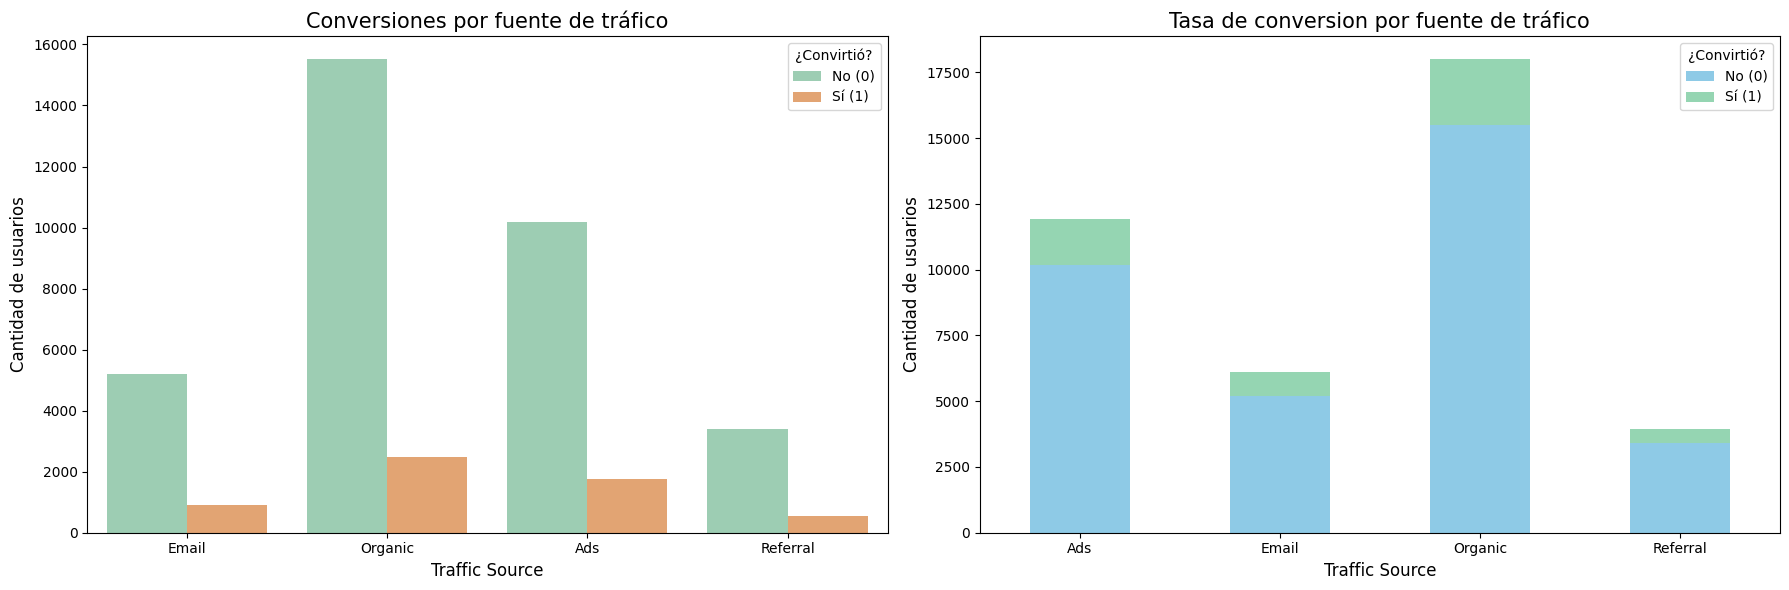

In [41]:
fig, axes= plt.subplots(1,2, figsize=(18,6))

sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por fuente de tráfico', fontsize=15)
axes[0].set_xlabel('Traffic Source', fontsize=12)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

tabla.plot(kind='bar', stacked= True, color=['#8ecae6','#95d5b2'], ax=axes[1])
axes[1].set_title('Tasa de conversion por fuente de tráfico', fontsize=15)
axes[1].set_xlabel('Traffic Source', fontsize=12)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Qué estamos viendo:**
Los gráficos comparan, para cada fuente de tráfico, cuántos usuarios convirtieron y cuántos no. El de la izquierda muestra las barras lado a lado y el de la derecha las apila, de modo que la altura total es el número de usuarios que trae cada canal y la parte verde es la proporción que convirtió.

**Hallazgos:**
- **Organic** es el canal con más usuarios (18,000) y, por volumen el que más conversiones aporta (2,480), seguido de **Ads** (1,759), **Email** (918) y **Referral** (549).
- En todos los canales la gran mayoría de los usuarios no convierte, y la franja de convertidos es pequeña frente al total.
- Las barras de convertidos son más altas en los canales con más tráfico, así que este gráfico refleja sobre todo el **volumen** de cada canal. Para comparar qué canal convierte mejor hay que mirar las tasas: Email (14.99%) y Ads (14.74%) superan a Referral (13.88%) y Organic (13.79%), con diferencias pequeñas, como mostró la prueba chi-cuadrado.

### Relación entre el tipo de usuario y la conversión

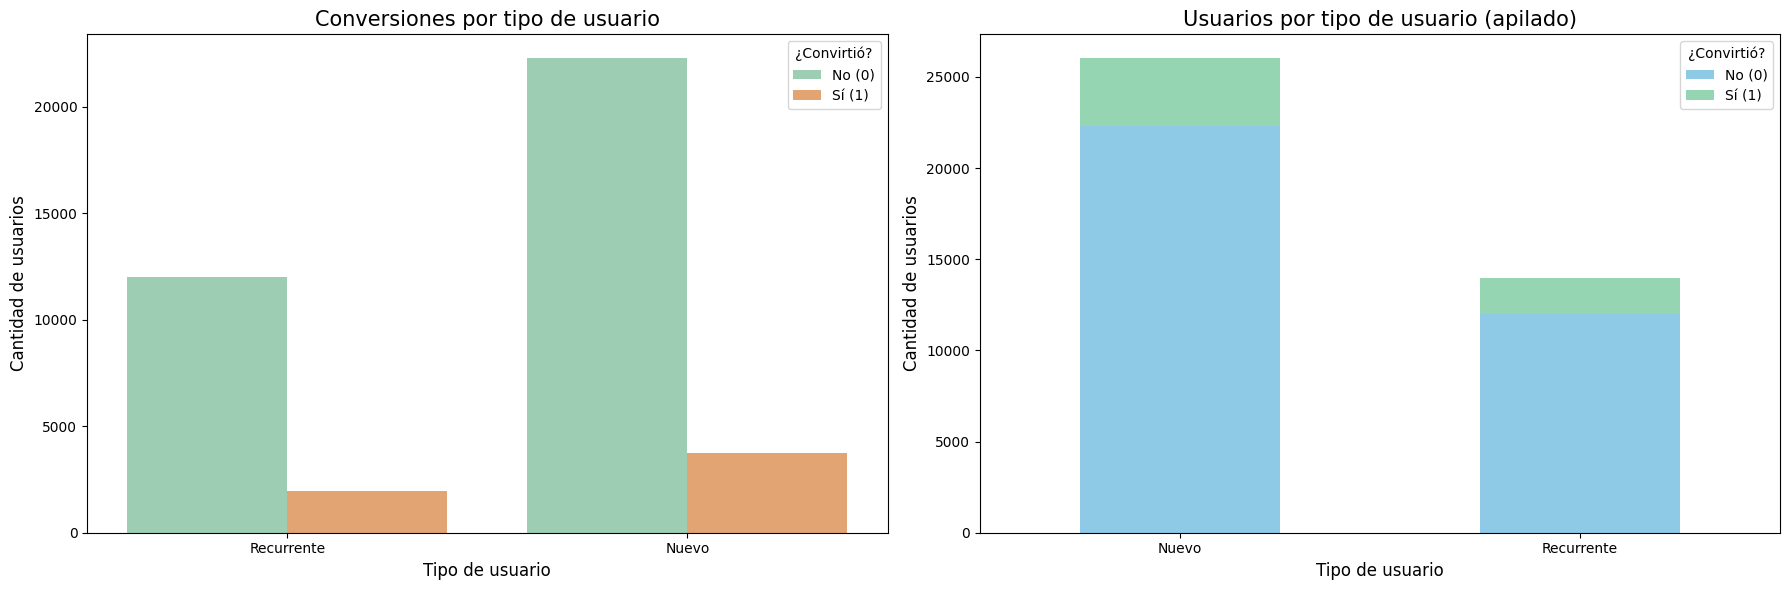

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: usuarios por tipo, según si convirtieron
sns.countplot(data=df, x='user_type', hue='converted',
              palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por tipo de usuario', fontsize=15)
axes[0].set_xlabel('Tipo de usuario', fontsize=12)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Gráfico 2: conteos apilados por tipo de usuario
tabla2.plot(kind='bar', stacked=True, color=['#8ecae6', '#95d5b2'], ax=axes[1])
axes[1].set_title('Usuarios por tipo de usuario (apilado)', fontsize=15)
axes[1].set_xlabel('Tipo de usuario', fontsize=12)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Qué estamos viendo:**
El gráfico de la izquierda compara cuántos usuarios nuevos y recurrentes convirtieron y cuántos no. El gráfico de la derecha apila a los usuarios de cada tipo según si convirtieron o no.

**Hallazgos:**
- Los usuarios nuevos son casi el doble de numerosos que los recurrentes (26,000 frente a 14,000), por lo que aportan más conversiones en cantidad absoluta.
- Las tasas de conversión son prácticamente iguales: 14.36% en usuarios nuevos y 14.09% en recurrentes. Las barras casi tienen la misma altura.
- Esto coincide con el resultado de la prueba chi-cuadrado (p = 0.474): no hay evidencia de que el tipo de usuario esté asociado con la conversión. Los nuevos convierten más en cantidad solo porque son más, no porque tengan mayor probabilidad de convertir.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

## Insight Ejecutivo basado en el Experimento A/B

### 7.1.1. 🔍 Comparación de página (A vs B)

**Gasto promedio por usuario que convirtió:**
- La página B tiene un gasto promedio de 68.75 por cliente convertido, frente a 61.09 de la página A (+7.66, 12.5% más).
- La diferencia es estadísticamente significativa (prueba t, p= 1e-20).
- **Interpretación:** los clientes que compran desde B gastan más en promedio. Como esta comparación incluye solo a quienes convirtieron, y la página pudo influir en quién compra, el resultado describe una asociación y no prueba que B cause por sí sola un mayor gasto.

**Tasa de conversión:**
- La página B convierte al 15.96% de sus usuarios y la A al 12.57%, una diferencia de 3.38 puntos porcentuales (27% más conversiones).
- La diferencia es significativa (prueba z, p = 1e-22).
- **Interpretación:** B convierte a más usuarios que A. Como los usuarios fueron asignados aleatoriamente y los grupos están balanceados, hay buen respaldo para atribuir esta mejora a la versión de la página, aunque la prueba no explica qué elemento del diseño la produce.

### 7.1.2. 📊 Segmentación por fuente de tráfico

- Organic aporta más conversiones en cantidad (2,480), seguido de Ads (1,759), Email (918) y Referral (549), pero esto refleja el volumen de cada canal. En tasa, Email (14.99%) y Ads (14.74%) superan a Referral (13.88%) y Organic (13.79%).
- La prueba chi-cuadrado indica asociación significativa (p = 0.034), aunque cercana al umbral.
- **Interpretación:** Email y Ads convierten ligeramente mejor, pero las diferencias son pequeñas (1.2 puntos entre el mejor y el peor canal). Organic sigue siendo clave por volumen, aunque es el canal con menor tasa.

### 8.0.1. 📊 Segmentación por tipo de usuario

- Los usuarios nuevos convierten al 14.36% y los recurrentes al 14.09%. La prueba chi-cuadrado no encuentra diferencia significativa (p = 0.474).
- **Interpretación:** el tipo de usuario no está asociado con la conversión. Los nuevos aportan más conversiones solo porque son más numerosos. No es una variable útil para segmentar.

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

### 8.0.2. 💡 Recomendaciones de negocio:

- **Implementar la página B** como versión principal: convierte significativamente más usuarios y sus clientes gastan más en promedio.
- **Reforzar Email y Ads** como canales con mayor tasa de conversión, sin descuidar Organic por su volumen. Dado que las diferencias entre canales son pequeñas, conviene validar con costos por canal antes de reasignar presupuesto.
- **No segmentar por tipo de usuario**, ya que no muestra diferencia en conversión. Esos esfuerzos se pueden orientar a otras variables.
- **Dar seguimiento después de implementar B:** monitorear conversión y gasto durante algunas semanas para confirmar que el efecto se mantiene fuera del experimento.